## 📊 SALES DATA ANALYSIS PROJECT

## Introduction
This project analyzes sales data to identify trends, top-performing countries, cities, and product categories. The goal is to extract meaningful insights that can help businesses make better decisions.

## Business Questions
- Which month has the highest sales?
- Which countries generate the most revenue?
- Which cities contribute the most to sales?
- Which product line performs the best?
- Is there any seasonal trend in sales?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Data Loading
The dataset is loaded using pandas for analysis.

In [2]:
data = pd.read_csv("C:/Users/shahm/OneDrive/Desktop/Project/sales_data_sample.csv", encoding='latin1')

## Data Cleaning
- Removed extra spaces from column names using `str.strip()` to ensure proper column access
- Converted ORDERDATE column to datetime format  
- Handled missing values using fillna() method  
- Numeric values filled with median  
- Categorical values filled with "Unknown"  
- Converted SALES column to numeric format using pd.to_numeric()

In [3]:
data.columns = data.columns.str.strip()

In [4]:
data['ORDERDATE'] = pd.to_datetime(data['ORDERDATE'], errors='coerce')

In [5]:
data = data.dropna(subset=['ORDERDATE'])

In [6]:
data.isnull().sum()

ORDERNUMBER            0
QUANTITYORDERED        0
PRICEEACH              0
ORDERLINENUMBER        0
SALES                  0
ORDERDATE              0
STATUS                 0
QTR_ID                 0
MONTH_ID               0
YEAR_ID                0
PRODUCTLINE            0
MSRP                   0
PRODUCTCODE            0
CUSTOMERNAME           0
PHONE                  0
ADDRESSLINE1           0
ADDRESSLINE2        2521
CITY                   0
STATE               1486
POSTALCODE            76
COUNTRY                0
TERRITORY           1074
CONTACTLASTNAME        0
CONTACTFIRSTNAME       0
DEALSIZE               0
dtype: int64

In [7]:
data['SALES'] = pd.to_numeric(data['SALES'], errors='coerce')
data['SALES'] = data['SALES'].fillna(data['SALES'].median())

In [8]:
data['ADDRESSLINE2'] = data['ADDRESSLINE2'].fillna("Not Available")
data['STATE'] = data['STATE'].fillna("Unknown")
data['POSTALCODE'] = data['POSTALCODE'].fillna("Unknown")
data['TERRITORY'] = data['TERRITORY'].fillna("Unknown")

In [9]:
data.isnull().sum()

ORDERNUMBER         0
QUANTITYORDERED     0
PRICEEACH           0
ORDERLINENUMBER     0
SALES               0
ORDERDATE           0
STATUS              0
QTR_ID              0
MONTH_ID            0
YEAR_ID             0
PRODUCTLINE         0
MSRP                0
PRODUCTCODE         0
CUSTOMERNAME        0
PHONE               0
ADDRESSLINE1        0
ADDRESSLINE2        0
CITY                0
STATE               0
POSTALCODE          0
COUNTRY             0
TERRITORY           0
CONTACTLASTNAME     0
CONTACTFIRSTNAME    0
DEALSIZE            0
dtype: int64

## Data Analysis
The dataset was analyzed to understand:
- Monthly sales trends
- Country-wise performance
- City-wise performance
- Product line performance
- Deal size contribution

In [10]:
total_revenue = round(data['SALES'].sum(), 2)
total_orders = data.shape[0]
avg_sales = round(data['SALES'].mean(), 2)

In [11]:
data['MONTH'] = data['ORDERDATE'].dt.month

## Data Visualization
Various charts were created to understand trends and patterns in the data, including line charts, bar charts, and heatmaps.

### 📅Monthly Sales Trend
This graph shows the monthly sales trend. Sales peak in November, indicating strong seasonal demand.

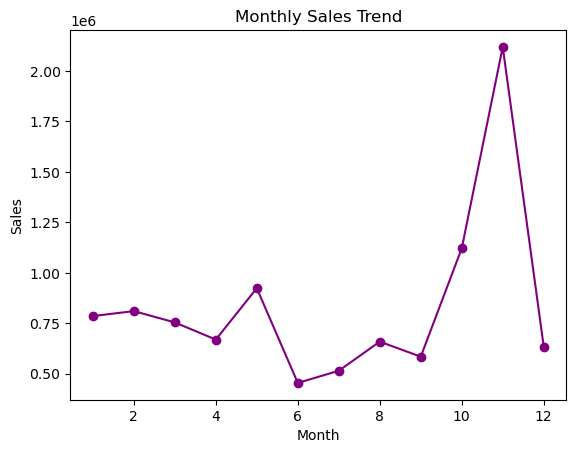

In [12]:
monthly_sales = data.groupby('MONTH')['SALES'].sum()

monthly_sales.plot(marker='o', color='purple')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.show()

### Top 🌍 5 Countries by Sales
This chart highlights the countries generating the highest revenue. USA, Spain, and France are the top contributors.

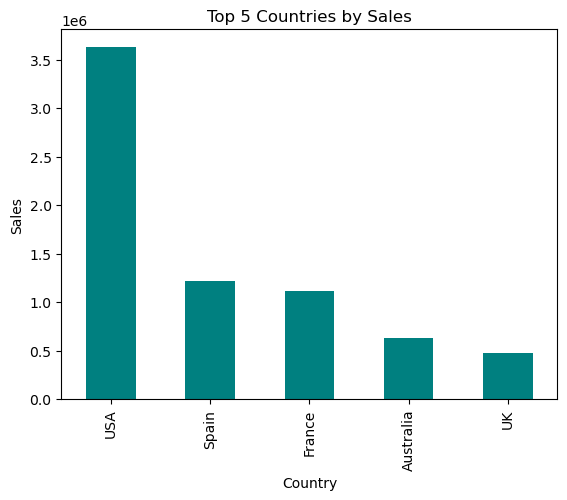

In [13]:
top_country = data.groupby('COUNTRY')['SALES'].sum().sort_values(ascending=False).head(5)

top_country.plot(kind='bar', color='teal')
plt.title("Top 5 Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Sales")
plt.show()


### Top 5 🏙️Cities by Sales
This chart shows the top-performing cities. These cities contribute significantly to overall sales.

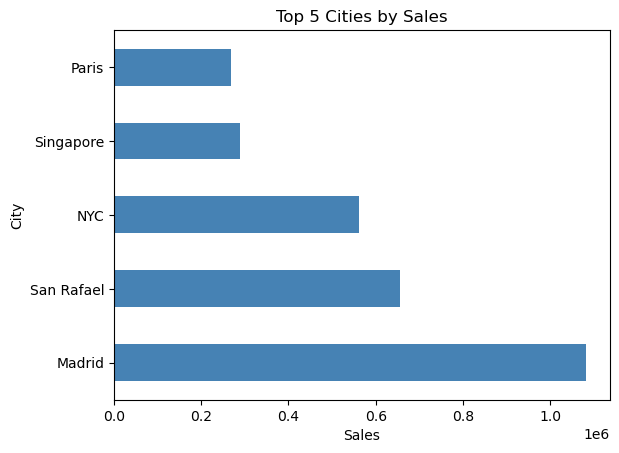

In [14]:
top_cities = data.groupby('CITY')['SALES'].sum().sort_values(ascending=False).head(5)

top_cities.plot(kind='barh', color='steelblue')
plt.title("Top 5 Cities by Sales")
plt.xlabel("Sales")
plt.ylabel("City")
plt.show()

### Sales by Product Line
This chart shows revenue distribution across product categories. Classic Cars generate the highest sales.

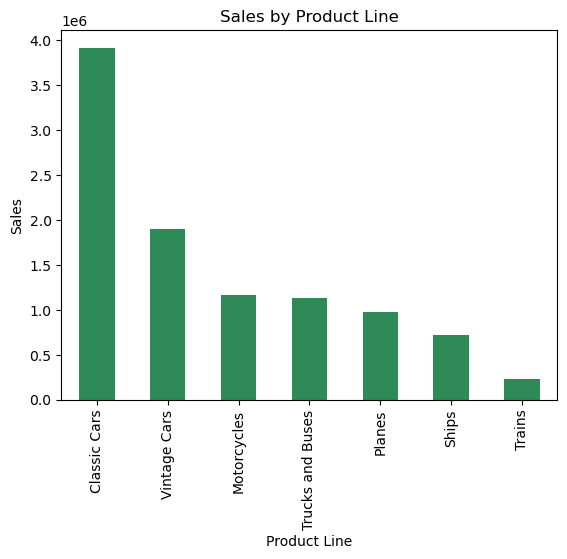

In [15]:
product_sales = data.groupby('PRODUCTLINE')['SALES'].sum().sort_values(ascending=False)

product_sales.plot(kind='bar', color='seagreen')
plt.title("Sales by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Sales")
plt.show()


### Deal Size Analysis
The deal size analysis highlights how different order sizes contribute to total revenue. Medium-sized deals contribute significantly, making them an important segment for business focus and strategy.

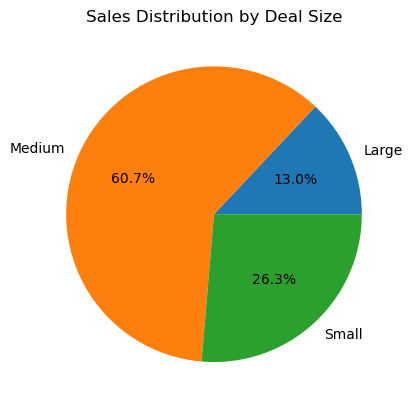

In [16]:
deal = data.groupby('DEALSIZE')['SALES'].sum()

deal.plot(kind='pie', autopct='%1.1f%%')
plt.title("Sales Distribution by Deal Size")
plt.ylabel('')
plt.show()


### Sales Heatmap (Month vs Year)
This heatmap visualizes sales patterns across months and years, showing strong seasonal trends with higher sales towards year-end.

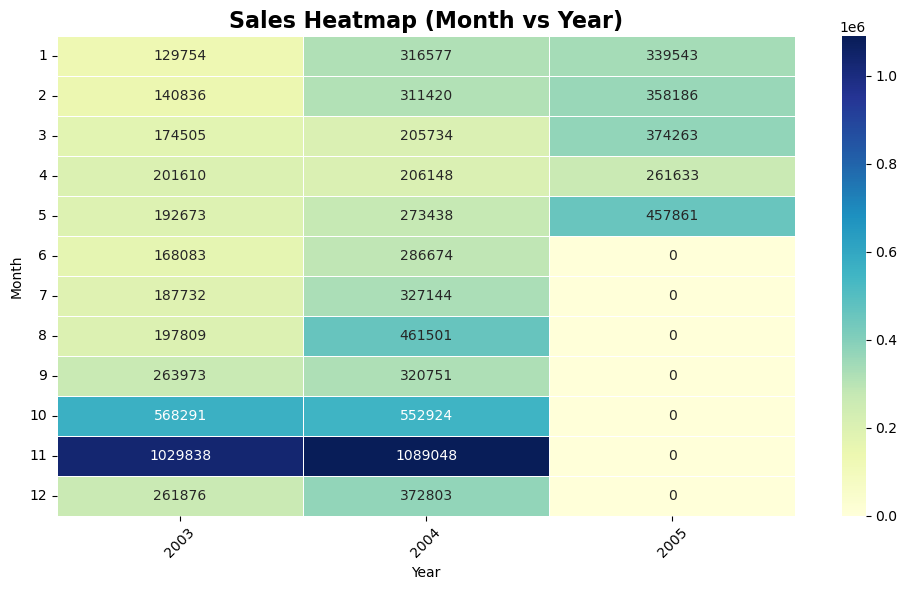

In [17]:
data['YEAR'] = data['ORDERDATE'].dt.year

pivot_table = data.pivot_table(
    values='SALES',
    index='MONTH',
    columns='YEAR',
    aggfunc='sum',
    fill_value=0
)

plt.figure(figsize=(10, 6)) 

sns.heatmap(
    pivot_table,
    annot=True,
    fmt=".0f",
    cmap="YlGnBu",   
    linewidths=0.5,  
    linecolor='white'
)

plt.title("Sales Heatmap (Month vs Year)", fontsize=16, fontweight='bold')
plt.xlabel("Year")
plt.ylabel("Month")
plt.yticks(rotation=0)   
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Key Metrics⭐
- Total Revenue: $10,032,628.85
- Total Orders: 2823
- Average Sales per Order: $3553.89

## Key Insights🚀
- Sales peak in November, indicating strong seasonal demand
- USA, Spain, and France are the top-performing countries
- Top cities contribute significantly to overall revenue
- Classic Cars generate the highest sales among all product lines
- Sales show an increasing trend towards the end of the year

## Recommendations❤️‍🔥
- Focus on high-performing markets like USA, Spain, and France
- Increase inventory for Classic Cars as they generate maximum revenue
- Plan marketing campaigns around November to maximize sales
- Target top-performing cities for business expansion


## 🎯Conclusion
This analysis provides valuable insights into sales trends, customer demand, and product performance. These insights can help businesses make data-driven decisions to improve overall performance.